In [1]:
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

In [2]:
%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import matplotlib as mpl

import regionmask
import geopandas as gpd
import pandas as pd
regionmask.__version__
#Yvans
import mw_protocol.plotting as plotting
import mw_protocol.saving as saving
import mw_protocol.glac1d_toolbox as tb
import pylaeoclim_leeds.util_hadcm3 as util

#Mine
import mymodules.myfunc as mf 


colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}

In [3]:
#Load necessary data
#Load Spans
exp_liste =  {'tfgbj':'17.8ka', 'xoupf':'18.2ka',  'tfgbr_xoupl':'19.4ka','tfgbi':'20.7ka'}
span_conditions, spans = {}, {}

for expt in exp_liste:
    with mf.Timer(f'{expt} load'):
        span_conditions[expt], spans[expt] = {}, {}
        data_folder = f"/nfs/see-fs-01_users/eelse/database/{expt}/perso/spans"
    
        for phase in ['cold', 'warming', 'merid', 'zonal', 'cooling']:
            span_conditions[expt][phase] = np.load(f"{data_folder}/{expt}.span_condition.{phase}.npy")
            spans[expt][phase] = np.load(f"{data_folder}/{expt}.spans.{phase}.npy")


#AMOC time series
amoc_ts = {}
amocf_ts = {}
filt = util.ButterLowPass(order=1, fc=2*10**-3, fs=1, mult=2)


for expt in exp_liste:
  with mf.Timer(f'{expt} AMOC load'):
    ts_full = xr.open_dataset(f"/nfs/see-fs-01_users/eelse/database/{expt}/time_series/{expt}.merid.annual.nc")
    ts = ts_full.drop_duplicates(dim='t')
    amoc_ts[expt] = ts.Merid_Atlantic.sel(latitude=26.5, method='nearest').max('depth').sortby('t')
    amocf_ts[expt] = filt.process(amoc_ts[expt].values)



[tfgbj load]
Elapsed: 0.5483200550079346
[xoupf load]
Elapsed: 0.5068647861480713
[tfgbr_xoupl load]
Elapsed: 0.3336610794067383
[tfgbi load]
Elapsed: 0.2524545192718506
[tfgbj AMOC load]
Elapsed: 69.64537596702576
[xoupf AMOC load]
Elapsed: 65.09253787994385
[tfgbr_xoupl AMOC load]
Elapsed: 55.92952346801758
[tfgbi AMOC load]
Elapsed: 71.93514347076416


In [12]:
from myconfig.EXPERIMENTS import EXPERIMENTS

skip = {"xqeic", "xqeie"}

for mode, scenarios in EXPERIMENTS.items():
    for scenario, info in scenarios.items():

        expt = info["exp"]

        if expt in skip:
            continue

        time = xr.open_dataset(
            f"/nfs/annie/earpal/database/experiments/{expt}/time_series/{expt}.dye00.annual.nc"
        )["t"]

        info["first_year"] = time.values[0].year
        info["last_year"] = time.values[-1].year

        time.close()


In [13]:
EXPERIMENTS

{'cold': {'20.7k': {'exp': 'xpujf',
   'nyears': 500,
   'first_year': 9391,
   'last_year': 9890},
  '19.4k': {'exp': 'xpuji',
   'nyears': 500,
   'first_year': 8761,
   'last_year': 9260},
  '18.2k': {'exp': 'xpujl',
   'nyears': 500,
   'first_year': 7001,
   'last_year': 7500},
  '17.8k': {'exp': 'xpraj',
   'nyears': 500,
   'first_year': 5681,
   'last_year': 6180},
  '17.8k_hires': {'exp': 'xqeic', 'nyears': 230}},
 'merid': {'20.7k': {'exp': 'xpujg',
   'nyears': 499,
   'first_year': 8271,
   'last_year': 8769},
  '19.4k': {'exp': 'xpujj',
   'nyears': 500,
   'first_year': 7941,
   'last_year': 8440},
  '18.2k': {'exp': 'xpujm',
   'nyears': 245,
   'first_year': 8321,
   'last_year': 8565},
  '17.8k': {'exp': 'xpral',
   'nyears': 500,
   'first_year': 6381,
   'last_year': 6880}},
 'zonal': {'20.7k': {'exp': 'xpujh',
   'nyears': 500,
   'first_year': 8521,
   'last_year': 9020},
  '19.4k': {'exp': 'xpujk',
   'nyears': 500,
   'first_year': 8151,
   'last_year': 8650},
  

In [19]:
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, FormatStrFormatter, MultipleLocator

color_spans = {'cold':'#484A6C', 
               'warming':'#FFABAB',
               'merid':'#C9381B', 
               'zonal':'#F59F00', 
               'cooling':'#B7DDF6'}

color_expts = {'xoupa':'black', 
              'xouph':'xkcd:bluey grey', 
              'xoupf':'xkcd:bluish', 
              'xoupk':'xkcd:bluish', 'tfgbi':'xkcd:bluish', 'tfgbj':'xkcd:bluish','tfgbr_xoupl':'xkcd:bluish',
               'xppbe':'xkcd:purple',
               'xppbf':'xkcd:bluish green'}

label_expts = {'xoupa':'CTRL', 
               'xouph':'21k', 
               'tfgbi':'20.7k', 
               'xoupk':'20.7k_tdc', 
               'tfgbr_xoupl':'19.4k',
               'xoupf':'18.2k',
               'xppbe':'20.7k with 21k GST',
               'xppbf':'20.7_no_gst',
               'tfgbj':'17.8k'}

modelyears_fordye = {}
modelyears_fordye['tfgbj']={'cold':[[4681,5180]], 
                       'merid':[[5381,5880],[3511,4011]], 
                       'zonal':[[4101,4601]]}
modelyears_fordye['tfgbi']={'cold':[[8395,8721]], 
                       'merid':[[7277,7523]], 
                       'zonal':[[7523,8185]]}
modelyears_fordye['xoupf']={'cold':[[6000, 6500]], 
                       'merid':[[7323, 7629]]}
modelyears_fordye['tfgbr_xoupl']={'cold':[[7759, 8233]],
                                  'merid':[[6940, 7155]],
                                'zonal': [[7155, 7535]] 
                                 }


Text(0.06, 0.5, 'AMOC Strength')

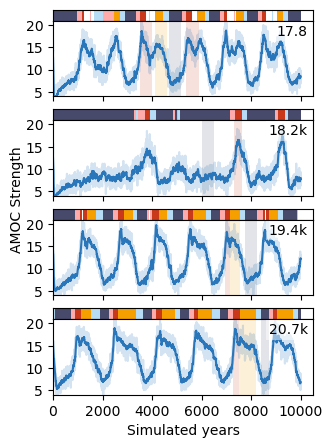

In [25]:
#Plot the plot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

exp_liste =  {'tfgbj':'17.8', 'xoupf':'18.2k',  'tfgbr_xoupl':'19.4k','tfgbi':'20.7k'}

# Create figure and grid specification
fig = plt.figure(figsize=(4, 5))

# Define the grid layout
grid = fig.add_gridspec(4, 1, hspace=0.15)

# Create subplots
for i,expt in enumerate(exp_liste):
    #expt= exp_liste[i]
    # Define the inner grid layout for each row
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=grid[i], height_ratios=[1, 7],hspace=0)

    # Add subplots for each row
    upper_ax = fig.add_subplot(inner_grid[0])
    for phase in spans[expt].keys():
        plt.imshow(np.expand_dims(span_conditions[expt][phase], axis=0), aspect='auto',
                                cmap = ListedColormap(['None', color_spans[phase]]),alpha=1)
    
    
    lower_ax = fig.add_subplot(inner_grid[1],sharex=upper_ax)
    for phase in modelyears_fordye[expt].keys():
        for span in modelyears_fordye[expt][phase]:
            plt.axvspan(span[0], span[1], alpha=0.15, linewidth=0, color=color_spans[phase])
        #plt.imshow(np.expand_dims(span_conditions[expt][phase], axis=0), aspect='auto',
         #                       cmap = ListedColormap(['None', color_spans[phase]]),alpha=0.15)
    plt.plot(amoc_ts[expt].t.dt.year-1000, util.rmean(amoc_ts[expt],30), color=color_expts[expt])
    plt.plot(amoc_ts[expt].t.dt.year-1000, amoc_ts[expt], color=color_expts[expt], alpha=0.2)
    # Remove x-axis labels
    upper_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    upper_ax.set_yticklabels([])
    #upper_ax.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False)
    #lower_ax.invert_yaxis()
    # Upper ax: remove all y-axis ticks and labels
    upper_ax.set_yticks([])

    # Lower ax: set y-tick spacing of 2
    lower_ax.yaxis.set_major_locator(plt.MultipleLocator(5))
    lower_ax.set_ylim(4,21)
    
    # Customize subplots if needed
    lower_ax.text(
    0.98, 0.95,                  # x, y in axes coordinates (0=left/bottom, 1=right/top)
    f"{exp_liste[expt]}",
    transform=lower_ax.transAxes,
    va='top', ha='right',
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=2),
    )
    if (i < 3):
        lower_ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
    else:
        lower_ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        lower_ax.set_xlabel('Simulated years')


    #lower_ax.set_ylabel('AMOC strength')
    #lower_ax.set_xlabel('Model years')
    #upper_ax.
    #lower_ax.set_title(f"Lower Section Row {i+1}")
    #lower_ax[2].set_xaxis('Model years')
# Show the plot
#plt.tight_layout()
#plt.show()

# Adjust layout to make space for the ylabel
plt.subplots_adjust(left=0.15, right=0.8, hspace=0.3)

# Set the ylabel spanning multiple rows
fig.text(0.06, 0.5, 'AMOC Strength', ha='center', va='center', rotation='vertical')




#plt.savefig("my_output/chapter-four_latestfigures/01_underlyingsim.pdf")




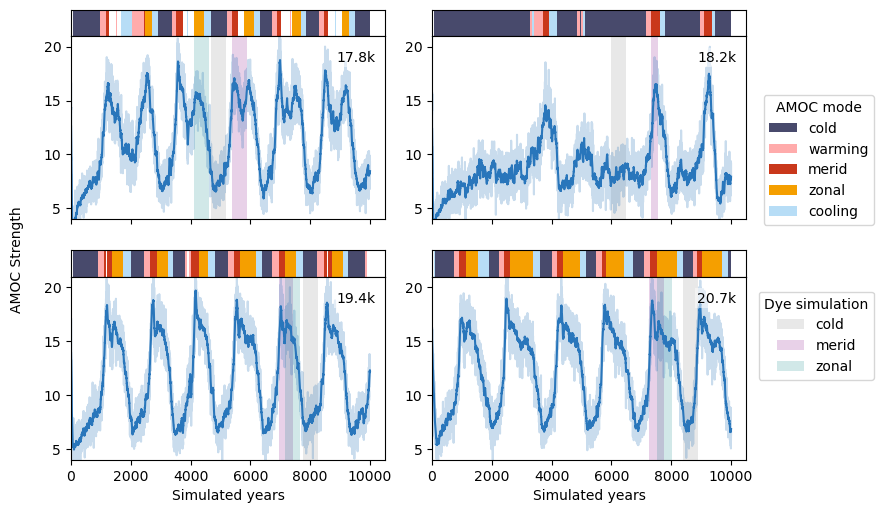

In [50]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

# Base simulations (AMOC time series)
exp_liste = {
    'tfgbj': '17.8k',
    'xoupf': '18.2k',
    'tfgbr_xoupl': '19.4k',
    'tfgbi': '20.7k'
}

# Branch simulations used for shading
# base simulation : branched experiments for the three AMOC states
shade_map = {
    "tfgbj": {
        "cold": "xpraj",
        "merid": "xpral",
        "zonal": "xprak",
    },
    "xoupf": {
        "cold": "xpujl",
        "merid": "xpujm",
    },
    "tfgbr_xoupl": {
        "cold": "xpuji",
        "merid": "xpujj",
        "zonal": "xpujk",
    },
    "tfgbi": {
        "cold": "xpujf",
        "merid": "xpujg",
        "zonal": "xpujh",
    },
}

# colours for shading
color_modes = {
    "cold": "grey",
    "merid": "purple",
    "zonal": "teal",
}


# --------------------------------------------------
# Create figure
# --------------------------------------------------

fig = plt.figure(figsize=(9, 5))

grid = fig.add_gridspec(
    2, 2,
    hspace=0.15,
    wspace=0.15
)


# --------------------------------------------------
# Plot panels
# --------------------------------------------------

axes = []

for i, expt in enumerate(exp_liste):

    row = i // 2
    col = i % 2

    inner_grid = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=grid[row, col],
        height_ratios=[1, 7],
        hspace=0
    )

    upper_ax = fig.add_subplot(inner_grid[0])
    lower_ax = fig.add_subplot(inner_grid[1], sharex=upper_ax)

    axes.append(lower_ax)


    # ----------------------------------------------
    # Top strip (your existing phase information)
    # ----------------------------------------------

    if expt in spans:

        for phase in spans[expt].keys():

            upper_ax.imshow(
                np.expand_dims(
                    span_conditions[expt][phase],
                    axis=0
                ),
                aspect='auto',
                cmap=ListedColormap(
                    ['None', color_spans[phase]]
                ),
                alpha=1
            )


    # ----------------------------------------------
    # Shading from branched simulations
    # ----------------------------------------------

    for mode, branch_exp in shade_map[expt].items():

        # find branch experiment in compiled dictionary
        for circulation, scenarios in EXPERIMENTS.items():

            for scenario, info in scenarios.items():

                if info["exp"] == branch_exp:

                    if "first_year" in info:

                        lower_ax.axvspan(
                            info["first_year"] - 1000,
                            info["last_year"] - 1000,
                            alpha=0.18,
                            linewidth=0,
                            color=color_modes[mode],
                            label=mode
                        )


    # ----------------------------------------------
    # AMOC time series from base simulation
    # ----------------------------------------------

    lower_ax.plot(
        amoc_ts[expt].t.dt.year - 1000,
        util.rmean(amoc_ts[expt], 30),
        color=color_expts[expt],
        linewidth=1.5
    )

    lower_ax.plot(
        amoc_ts[expt].t.dt.year - 1000,
        amoc_ts[expt],
        color=color_expts[expt],
        alpha=0.25
    )


    # ----------------------------------------------
    # Formatting
    # ----------------------------------------------

    upper_ax.set_yticks([])

    upper_ax.tick_params(
        axis='x',
        bottom=False,
        labelbottom=False
    )


    lower_ax.yaxis.set_major_locator(
        plt.MultipleLocator(5)
    )

    lower_ax.set_ylim(4, 21)


    lower_ax.text(
        0.97,
        0.92,
        exp_liste[expt],
        transform=lower_ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(
            facecolor='white',
            alpha=0.5,
            edgecolor='none',
            pad=2
        )
    )


# x-axis only on bottom row
for ax in axes[:2]:
    ax.tick_params(
        axis='x',
        labelbottom=False
    )

for ax in axes[2:]:
    ax.set_xlabel("Simulated years")


# y label
fig.text(
    0.04,
    0.5,
    "AMOC Strength",
    ha="center",
    va="center",
    rotation="vertical"
)


# optional legend for shading
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    title="Dye simulation",
    bbox_to_anchor=(1, 0.45),
    frameon=True
)


# --------------------------------------------------
# Legend for top bar phases
# --------------------------------------------------

phase_colors = {
    "cold": color_spans["cold"],
    "warming": color_spans["warming"],
    "merid": color_spans["merid"],
    "zonal": color_spans["zonal"],
    "cooling": color_spans["cooling"],
}

phase_handles = [
    Patch(
        facecolor=phase_colors[phase],
        edgecolor="none",
        label=phase
    )
    for phase in ['cold', 'warming', 'merid', 'zonal', 'cooling']
]


fig.legend(
    handles=phase_handles,
    title="AMOC mode",
    loc="right",
    bbox_to_anchor=(1, 0.7),
    ncol=1,
    frameon=True,
)


plt.subplots_adjust(
    left=0.1,
    right=0.85,
    bottom=0.1,
    top=1
)


plt.savefig("my_output/chapter-four_latestfigures/AFig1_underlyingsim.pdf")


plt.show()